# 01 - Exploratory Data Analysis
Freight rate prediction: understand the data before modeling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Load data
Load the three files with `date` parsed as datetime, then sanity-check shapes and date ranges.

In [2]:
DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR / "train_test.csv", parse_dates=["date"])
val = pd.read_csv(DATA_DIR / "validation.csv", parse_dates=["date"])
dec = pd.read_csv(DATA_DIR / "december_chart_inputs.csv", parse_dates=["date"])

for name, df in [("train", train), ("validation", val), ("december", dec)]:
    print(f"{name:<11} shape={df.shape}  dates: {df['date'].min().date()} -> {df['date'].max().date()}")

train       shape=(48000, 14)  dates: 2025-01-01 -> 2025-10-31
validation  shape=(12000, 13)  dates: 2025-11-01 -> 2025-12-31
december    shape=(31, 7)  dates: 2025-12-01 -> 2025-12-31


## 2. Missing values
Which columns have missing values, how many, and does the validation set have the same problem?

In [3]:
missing = pd.DataFrame({
    "train_count": train.isna().sum(),
    "train_pct": train.isna().mean().mul(100).round(2),
    "val_count": val.isna().sum(),
    "val_pct": val.isna().mean().mul(100).round(2),
    "dec_count": dec.drop(columns="predicted_rate").isna().sum(),
})
missing[(missing["train_count"] > 0) | (missing["val_count"] > 0)]

,train_count,train_pct,val_count,val_pct,dec_count
market_index,374,0.78,249.0,2.08,NaN
weight,300,0.62,165.0,1.38,0.0


### 2.1 Is the missingness random?
If missing rows differ from the rest (price, month, equipment), the fact that a value is missing carries information.

In [4]:
train["rate_per_mile"] = train["posted_rate"] / train["distance"]
print("rows missing both weight and market_index:", (train["weight"].isna() & train["market_index"].isna()).sum(), "\n")

for col in ["weight", "market_index"]:
    is_missing = train[col].isna()
    print(f"--- {col} ---")
    print("median rate_per_mile  missing: %.3f | present: %.3f" % (
        train.loc[is_missing, "rate_per_mile"].median(),
        train.loc[~is_missing, "rate_per_mile"].median(),
    ))
    print("missing % by equipment:", train.groupby("equipment")[col].apply(lambda s: round(s.isna().mean() * 100, 2)).to_dict())
    print("missing % by month:   ", train.groupby(train["date"].dt.month)[col].apply(lambda s: round(s.isna().mean() * 100, 2)).to_dict())
    print()

rows missing both weight and market_index: 1 

--- weight ---
median rate_per_mile  missing: 2.118 | present: 2.146
missing % by equipment: {'Dry Van': 0.64, 'Flatbed': 0.63, 'Reefer': 0.58}
missing % by month:    {1: 0.69, 2: 0.76, 3: 0.71, 4: 0.42, 5: 0.45, 6: 0.67, 7: 0.59, 8: 0.61, 9: 0.71, 10: 0.66}

--- market_index ---
median rate_per_mile  missing: 2.121 | present: 2.145
missing % by equipment: {'Dry Van': 0.74, 'Flatbed': 0.83, 'Reefer': 0.82}
missing % by month:    {1: 0.73, 2: 0.83, 3: 0.87, 4: 0.64, 5: 0.88, 6: 0.88, 7: 0.73, 8: 0.69, 9: 0.66, 10: 0.87}



### 2.2 Do missing-weight rows have different distances?
Compare the two groups (weight missing = True / present = False) against the natural spread (`std`).

In [5]:
train.groupby(train["weight"].isna())["distance"].describe()

,count,mean,std,min,25%,50%,75%,max
weight,,,,,,,,
False,47700.0,1135.796117,728.516704,70.0,550.40,953.3,1645.500,3439.8
True,300.0,1145.482000,737.277714,107.0,549.35,944.4,1681.875,3237.4


**Finding (2.1 + 2.2):** rows with missing values look like the rest on price per mile, distance, equipment and month.
The gaps are tiny compared to the natural spread (e.g. rate per mile 2.118 vs 2.146, std 0.58).
Missingness looks random (MCAR), so a missing flag would add no information.

### 2.3 Does weight differ by equipment?
If equipment types had different typical weights, filling by equipment would be more accurate than one global value.

In [6]:
# abs(): 292 rows have negative weight, handled in a later section
train["weight"].abs().groupby(train["equipment"]).median()

equipment
Dry Van    31444.0
Flatbed    31532.5
Reefer     31577.0
Name: weight, dtype: float64

**Finding:** medians are almost identical (~31.4k-31.6k lb), so filling by equipment adds nothing over one global median.

### 2.4 market_index: does it move day to day?
If the value changes a lot between days but little within a day, the day's median is a better fill than one global median.

<Axes: title={'center': 'market_index: daily mean'}, xlabel='date'>

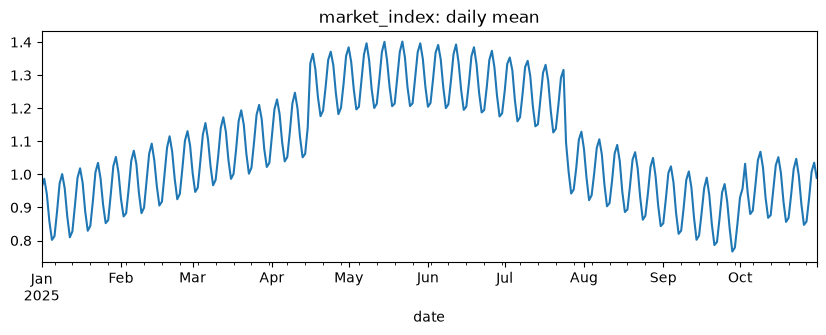

In [7]:
daily = train.groupby("date")["market_index"].mean()
daily.plot(figsize=(10, 3), title="market_index: daily mean")

In [8]:
within_day_std = train.groupby("date")["market_index"].std().mean()
between_day_std = daily.std()
print(f"std inside one day (avg): {within_day_std:.3f}")
print(f"std between daily means:  {between_day_std:.3f}")

std inside one day (avg): 0.025
std between daily means:  0.167


**Test:** take rows where `market_index` is known, pretend it is missing, and measure the error (MAE) of each fill method.
Note: the day's median includes the row itself, which flatters it slightly; with 115-198 rows per day the effect is negligible.

In [9]:
known = train.dropna(subset=["market_index"])
global_median = known["market_index"].median()
day_median = known.groupby("date")["market_index"].transform("median")

err_global = (known["market_index"] - global_median).abs().mean()
err_day = (known["market_index"] - day_median).abs().mean()

print(f"global median = {global_median:.3f}")
print(f"avg error, global median: {err_global:.3f}")
print(f"avg error, daily median:  {err_day:.3f}")

global median = 1.056
avg error, global median: 0.143
avg error, daily median:  0.020


**Finding:** within-day std 0.025 vs between-day std 0.167. Daily-median fill error is 0.020 vs 0.143 for a global median (~7x better).

### 2.5 Same checks on the validation set
The validation set has no prices, so we can only compare features. Questions: is its missingness also random, and does every validation day have enough known `market_index` values to compute a daily median?

In [10]:
for col in ["weight", "market_index"]:
    m = val[col].isna()
    print(f"--- {col}: {m.sum()} missing ({m.mean() * 100:.2f}%) | train: {train[col].isna().mean() * 100:.2f}% ---")
    print("median distance  missing: %.1f | present: %.1f | std: %.1f" % (
        val.loc[m, "distance"].median(),
        val.loc[~m, "distance"].median(),
        val["distance"].std(),
    ))
    print("missing % by equipment:", val.groupby("equipment")[col].apply(lambda s: round(s.isna().mean() * 100, 2)).to_dict())
    print("missing % by month:   ", val.groupby(val["date"].dt.month)[col].apply(lambda s: round(s.isna().mean() * 100, 2)).to_dict())
    per_day = val.groupby("date")[col].apply(lambda s: s.isna().mean() * 100)
    print("worst single day: %.2f%% missing" % per_day.max())
    print()

--- weight: 165 missing (1.38%) | train: 0.62% ---
median distance  missing: 962.3 | present: 953.6 | std: 732.3
missing % by equipment: {'Dry Van': 1.49, 'Flatbed': 1.29, 'Reefer': 1.18}
missing % by month:    {11: 1.41, 12: 1.35}
worst single day: 3.06% missing

--- market_index: 249 missing (2.08%) | train: 0.78% ---
median distance  missing: 1024.6 | present: 952.2 | std: 732.3
missing % by equipment: {'Dry Van': 2.05, 'Flatbed': 1.75, 'Reefer': 2.36}
missing % by month:    {11: 1.97, 12: 2.17}
worst single day: 4.29% missing



In [11]:
val_known = val.dropna(subset=["market_index"])
by_day = val_known.groupby("date")["market_index"]

print("validation days:", val["date"].nunique(), "| fewest known rows on any day:", by_day.size().min())
print("std inside one day (avg): %.3f" % by_day.std().mean())
print("std between daily means:  %.3f" % by_day.mean().std())
print("median market_index  train: %.3f | validation: %.3f" % (train["market_index"].median(), val["market_index"].median()))

validation days: 61 | fewest known rows on any day: 159
std inside one day (avg): 0.025
std between daily means:  0.071
median market_index  train: 1.056 | validation: 0.923


**Finding:** validation has about 2-3x the missing rate of train (weight 1.38% vs 0.62%, market_index 2.08% vs 0.78%), spread evenly across equipment, months and days (worst day 4.3%).
Rows with missing values are not meaningfully different in distance (the market_index gap of ~72 miles is about 1 standard error with 249 rows).
Every validation day has at least 159 known `market_index` values, so a daily median can be computed for all 61 days.
`market_index` still varies more between days (std 0.071) than within a day (0.025), but the level shifted: train median 1.056 vs validation median 0.923. A train-wide median would be off by ~0.13 on validation.

**Test:** validation days (Nov-Dec) do not exist in train. Take validation rows where `market_index` is known, pretend it is missing, and compare four ways to fill it (average absolute error).

In [12]:
known = val.dropna(subset=["market_index"])
same_day = known.groupby("date")["market_index"].transform("median")
oct_median = train.loc[train["date"].dt.month == 10, "market_index"].median()
last_day_median = train.loc[train["date"] == train["date"].max(), "market_index"].median()

options = {
    "A: same-day median (validation rows)": same_day,
    "B: train global median": train["market_index"].median(),
    "C: train October median": oct_median,
    "D: train last-day median": last_day_median,
}
for name, fill in options.items():
    print(f"{name:<40} avg error: {(known['market_index'] - fill).abs().mean():.3f}")

A: same-day median (validation rows)     avg error: 0.020
B: train global median                   avg error: 0.129
C: train October median                  avg error: 0.068
D: train last-day median                 avg error: 0.079


**Finding:** A is about 3x more accurate than the best train-based option (0.020 vs 0.068). It uses only features of the same day, never prices.

### 2.6 Negative weight: sign error or something else?
If the negative values are the same weights with a flipped sign, `abs()` keeps the information. If they behave differently (price, equipment, month), they would need another treatment.

In [13]:
neg = train[train["weight"] < 0]
pos = train[train["weight"] > 0]

print("negative weight rows  train: %d | validation: %d" % ((train["weight"] < 0).sum(), (val["weight"] < 0).sum()))

quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]
print("abs(negative) quantiles:", neg["weight"].abs().quantile(quantiles).round(0).tolist())
print("positive quantiles:     ", pos["weight"].quantile(quantiles).round(0).tolist())
print("median rate_per_mile  negative: %.3f | positive: %.3f" % (neg["rate_per_mile"].median(), pos["rate_per_mile"].median()))

negative weight rows  train: 292 | validation: 145
abs(negative) quantiles: [18966.0, 25928.0, 31822.0, 37284.0, 46070.0]
positive quantiles:      [18004.0, 25922.0, 31494.0, 37063.0, 44962.0]
median rate_per_mile  negative: 2.157 | positive: 2.145


**Finding:** the absolute values of the negative weights have the same distribution as the positive ones (same quantiles), and their rate per mile and price are the same (2.157 vs 2.145). Negative rows are spread evenly across equipment and months (0.3%-0.8%).
So only the sign is corrupted, not the magnitude. Validation has twice the rate (1.23% vs 0.61%), so the pipeline must apply `abs()` to validation as well.

## 3. Rate per mile vs distance
`posted_rate` is the total price of the load in USD. Comparing price **per mile** removes the effect of distance.

In [14]:
bands = pd.cut(train["distance"], [0, 250, 500, 1000, 2000, 4000])
train.groupby(bands, observed=True)["rate_per_mile"].median()

distance
(0, 250]        2.745114
(250, 500]      2.423025
(500, 1000]     2.195226
(1000, 2000]    2.045645
(2000, 4000]    1.911825
Name: rate_per_mile, dtype: float64

**Finding:** shorter loads cost more per mile (fixed costs such as loading and unloading are spread over fewer miles). Total price still rises with distance.

## 4. Price outliers
A load is an outlier when its rate per mile is far from what is normal **for its distance** (short loads are naturally pricier per mile).
`rpm_ratio` = the load's rate per mile divided by the median rate per mile of its distance band. 1 means normal, 5 means five times normal, 0.2 means a fifth of normal.

In [15]:
bands = pd.cut(train["distance"], [0, 150, 250, 500, 1000, 2000, 4000])
expected_rpm = train.groupby(bands, observed=True)["rate_per_mile"].transform("median")
train["rpm_ratio"] = train["rate_per_mile"] / expected_rpm

train["rpm_ratio"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(3)

count    48000.000
mean         1.020
std          0.246
min          0.164
1%           0.838
5%           0.887
50%          1.000
95%          1.151
99%          1.231
max          5.867
Name: rpm_ratio, dtype: float64

### 4.1 See it
Left: how many loads have each ratio (log scale so the small groups are visible). Dashed lines mark the gap used to flag outliers (0.6 and 1.6).
Right: price vs distance, with flagged loads highlighted.

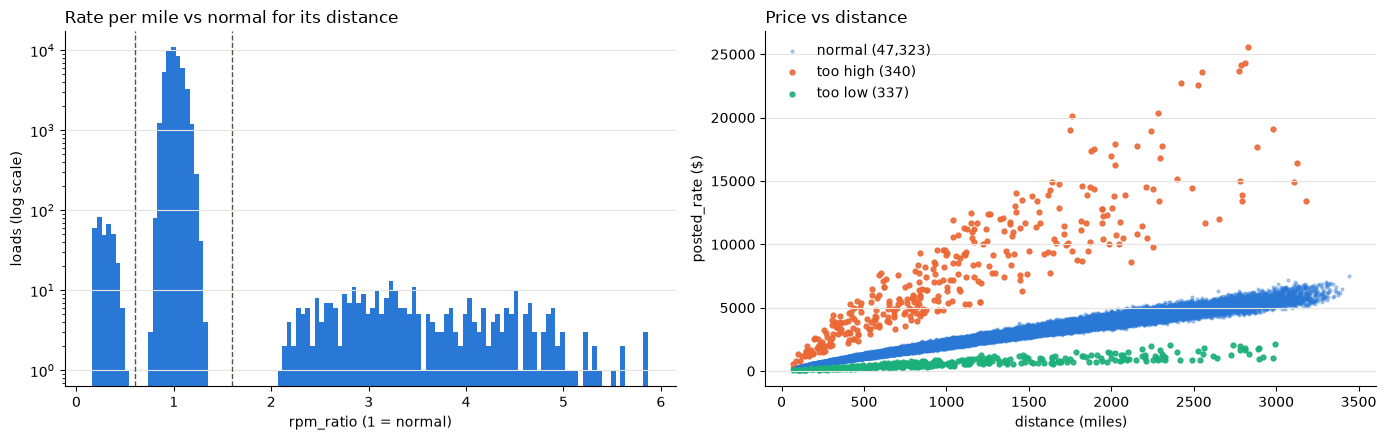

In [16]:
LOW, HIGH = 0.6, 1.6
train["price_group"] = np.select(
    [train["rpm_ratio"] < LOW, train["rpm_ratio"] > HIGH],
    ["too low", "too high"],
    default="normal",
)
colors = {"normal": "#2a78d6", "too high": "#eb6834", "too low": "#1baf7a"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.hist(train["rpm_ratio"].clip(0, 6), bins=120, color=colors["normal"])
ax1.set_yscale("log")
for x in (LOW, HIGH):
    ax1.axvline(x, color="#52514e", linestyle="--", linewidth=1)
ax1.set_title("Rate per mile vs normal for its distance", loc="left")
ax1.set_xlabel("rpm_ratio (1 = normal)")
ax1.set_ylabel("loads (log scale)")

for group in ["normal", "too high", "too low"]:
    part = train[train["price_group"] == group]
    ax2.scatter(
        part["distance"],
        part["posted_rate"],
        s=4 if group == "normal" else 12,
        alpha=0.35 if group == "normal" else 0.9,
        color=colors[group],
        label=f"{group} ({len(part):,})",
    )
ax2.set_title("Price vs distance", loc="left")
ax2.set_xlabel("distance (miles)")
ax2.set_ylabel("posted_rate ($)")
ax2.legend(frameon=False)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
plt.tight_layout()
plt.show()

### 4.2 Who are they?
If outliers cluster in an equipment type, a month or a market condition, a model could learn them. If not, they are noise.

In [17]:
normal = train[train["price_group"] == "normal"]
is_outlier = train["price_group"] != "normal"

print(train["price_group"].value_counts().to_string())
print(f"outlier share: {is_outlier.mean() * 100:.2f}%\n")

print("rate_per_mile std  all rows: %.3f | normal only: %.3f" % (train["rate_per_mile"].std(), normal["rate_per_mile"].std()))
print("max posted_rate    all rows: %.0f | normal only: %.0f\n" % (train["posted_rate"].max(), normal["posted_rate"].max()))

print("outlier % by equipment:", is_outlier.groupby(train["equipment"]).mean().mul(100).round(2).to_dict())
print("outlier % by month:    ", is_outlier.groupby(train["date"].dt.month).mean().mul(100).round(2).to_dict())
print("market_index median  outliers: %.3f | normal: %.3f" % (train.loc[is_outlier, "market_index"].median(), normal["market_index"].median()))
print("quote_signal median  outliers: %.3f | normal: %.3f" % (train.loc[is_outlier, "quote_signal"].median(), normal["quote_signal"].median()))

price_group
normal      47323
too high      340
too low       337
outlier share: 1.41%

rate_per_mile std  all rows: 0.584 | normal only: 0.273
max posted_rate    all rows: 25533 | normal only: 7498

outlier % by equipment: {'Dry Van': 1.35, 'Flatbed': 1.45, 'Reefer': 1.51}
outlier % by month:     {1: 1.65, 2: 1.31, 3: 1.41, 4: 1.37, 5: 1.26, 6: 1.32, 7: 1.32, 8: 1.43, 9: 1.37, 10: 1.65}
market_index median  outliers: 1.048 | normal: 1.056
quote_signal median  outliers: 2.040 | normal: 2.056


### 4.3 Why not the usual IQR rule?
The standard rule flags values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR. Applied to three different columns, compared with the gap-based flags from 4.1:

In [18]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

gap_flag = train["price_group"] != "normal"
for col in ["posted_rate", "rate_per_mile", "rpm_ratio"]:
    low, high = iqr_bounds(train[col])
    flag = (train[col] < low) | (train[col] > high)
    print(
        f"{col:<14} bounds {low:9.2f} .. {high:8.2f} | flagged {flag.sum():5d} | "
        f"gap outliers caught {(flag & gap_flag).sum()}/{gap_flag.sum()} | normal loads flagged {(flag & ~gap_flag).sum()}"
    )

posted_rate    bounds  -1867.24 ..  6449.54 | flagged   260 | gap outliers caught 177/677 | normal loads flagged 83
rate_per_mile  bounds      1.45 ..     2.88 | flagged  1634 | gap outliers caught 677/677 | normal loads flagged 957
rpm_ratio      bounds      0.78 ..     1.23 | flagged   824 | gap outliers caught 677/677 | normal loads flagged 147


**Finding:** IQR on `posted_rate` misses most outliers (177 of 677) and flags 83 normal long-distance loads, because price depends on distance.
IQR on `rate_per_mile` catches all of them but flags 957 normal short loads (short loads are naturally pricier per mile).
Comparing each load with the normal price **for its distance** (`rpm_ratio`) and cutting at the visible gaps separates the two groups cleanly.

**Options considered:**

| Option | How | Pro | Con |
|---|---|---|---|
| 1. Keep | Train on all rows | Simple, no rule | Noise pulls the model |
| 2. Drop from training | Remove flagged rows from the training part only | Model learns from clean prices | Rule uses the price; fine for training, must be explained |
| 3. Clip | Cap prices at a limit | No rows lost | Invents prices that never existed |
| 4. Robust loss | Keep rows, train with MAE / Huber loss | Model down-weights them itself, no rule | Depends on the model and its settings |

Whatever the choice, report validation error both on all rows and on normal rows only.

**Decision:** option 2, drop flagged rows from the training part only (see Decisions log #7).

## 5. quote_signal
Question: what is `quote_signal`, and can we trust it for Nov-Dec?

In [19]:
normal_rows = train[train["price_group"] == "normal"]

for month in [1, 4, 8]:
    part = normal_rows[normal_rows["date"].dt.month == month]
    slope, intercept = np.polyfit(part["rate_per_mile"], part["quote_signal"], 1)
    noise = (part["quote_signal"] - (intercept + slope * part["rate_per_mile"])).std()
    print(f"month {month}: quote_signal = {intercept:.3f} + {slope:.3f} * rate_per_mile   (noise std {noise:.3f})")

month 1: quote_signal = -0.001 + 1.000 * rate_per_mile   (noise std 0.022)
month 4: quote_signal = 4.154 + -1.002 * rate_per_mile   (noise std 0.030)
month 8: quote_signal = 2.090 + -0.017 * rate_per_mile   (noise std 0.223)


### 5.1 Week by week
Top: correlation between `quote_signal` and rate per mile, per week (train only, because it needs prices).
Bottom: correlation between `quote_signal` and distance, per week, for train **and** validation. This needs no prices: when `quote_signal` follows rate per mile, it also follows distance (short loads are pricier per mile), so this line tells us which regime a week is in even without prices.

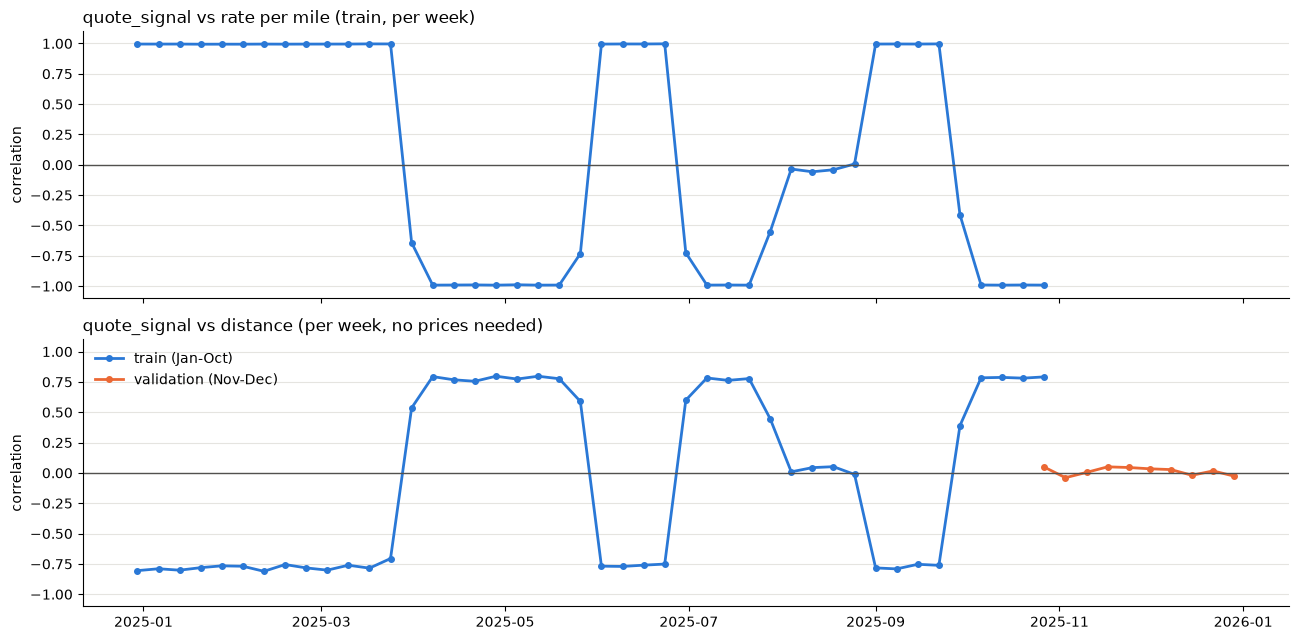

In [20]:
def weekly_corr(df, col):
    # Spearman correlation = Pearson correlation of the ranks
    return df.groupby(df["date"].dt.to_period("W").dt.start_time).apply(
        lambda g: g["quote_signal"].rank().corr(g[col].rank())
    )

corr_rpm_train = weekly_corr(normal_rows, "rate_per_mile")
corr_dist_train = weekly_corr(train, "distance")
corr_dist_val = weekly_corr(val, "distance")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)

ax1.plot(corr_rpm_train.index, corr_rpm_train.values, color="#2a78d6", linewidth=2, marker="o", markersize=4)
ax1.set_title("quote_signal vs rate per mile (train, per week)", loc="left")
ax1.set_ylabel("correlation")

ax2.plot(corr_dist_train.index, corr_dist_train.values, color="#2a78d6", linewidth=2, marker="o", markersize=4, label="train (Jan-Oct)")
ax2.plot(corr_dist_val.index, corr_dist_val.values, color="#eb6834", linewidth=2, marker="o", markersize=4, label="validation (Nov-Dec)")
ax2.set_title("quote_signal vs distance (per week, no prices needed)", loc="left")
ax2.set_ylabel("correlation")
ax2.legend(frameon=False, loc="upper left")

for ax in (ax1, ax2):
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.set_ylim(-1.1, 1.1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
plt.tight_layout()
plt.show()

**Finding:**
- In Jan-Mar, Jun and Sep, `quote_signal` is the rate per mile itself (slope 1.000, intercept 0, tiny noise).
- In Apr-May, Jul and Oct, it is a mirror of it: `quote_signal ≈ 4.15 - rate_per_mile`.
- In Aug it is noise with no link to price.
- So in most of train, `quote_signal` almost contains the answer. A model would rely on it heavily.
- In Nov-Dec its link with distance is ~0 every week, like August, so it most likely carries no price information there. This is indirect evidence (validation has no prices), but the same check identifies the regime correctly on 97.7% of train days.

## 6. What drives price?
Distance is the main driver (section 3). To see the other drivers fairly, every load is compared with the typical price **for its distance**:
`pct_vs_typical` = (`rpm_ratio` - 1) x 100. For example +8% means 8% more expensive than a typical load of the same distance.
Outliers (section 4) are excluded.

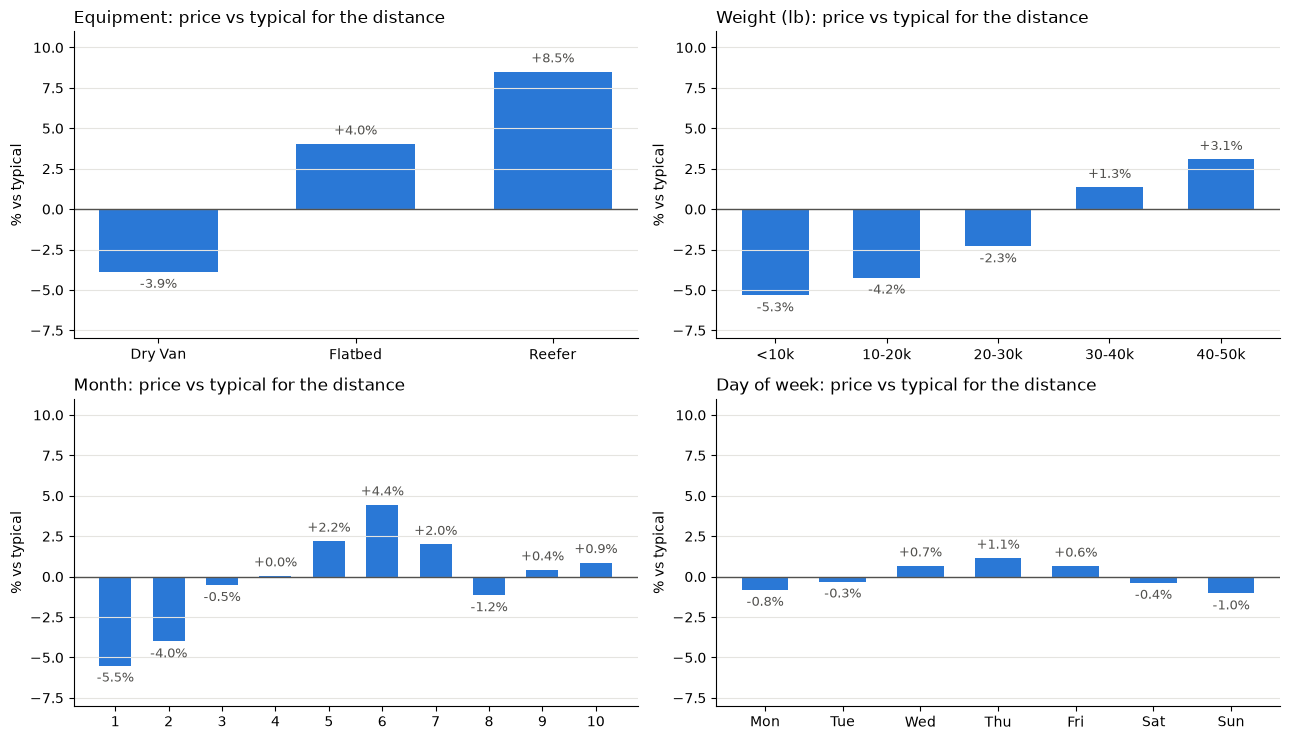

In [21]:
clean = train[train["price_group"] == "normal"].copy()
clean["pct_vs_typical"] = (clean["rpm_ratio"] - 1) * 100
clean["weight_band"] = pd.cut(
    clean["weight"].abs(),
    [0, 10000, 20000, 30000, 40000, 50000],
    labels=["<10k", "10-20k", "20-30k", "30-40k", "40-50k"],
)

by_equipment = clean.groupby("equipment")["pct_vs_typical"].median()
by_weight = clean.groupby("weight_band", observed=True)["pct_vs_typical"].median()
by_month = clean.groupby(clean["date"].dt.month)["pct_vs_typical"].median()
by_weekday = clean.groupby(clean["date"].dt.dayofweek)["pct_vs_typical"].median()
by_weekday.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
panels = [
    (axes[0, 0], by_equipment, "Equipment"),
    (axes[0, 1], by_weight, "Weight (lb)"),
    (axes[1, 0], by_month, "Month"),
    (axes[1, 1], by_weekday, "Day of week"),
]
for ax, series, title in panels:
    labels = [str(i) for i in series.index]
    ax.bar(labels, series.values, color="#2a78d6", width=0.6)
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.set_title(f"{title}: price vs typical for the distance", loc="left")
    ax.set_ylabel("% vs typical")
    ax.set_ylim(-8, 11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    for x, y in zip(labels, series.values):
        ax.text(x, y + (0.4 if y >= 0 else -0.4), f"{y:+.1f}%", ha="center",
                va="bottom" if y >= 0 else "top", fontsize=9, color="#52514e")
plt.tight_layout()
plt.show()

### 6.1 Does market_index explain the daily price level?
Each dot is one day: that day's median `market_index` against that day's median price level.
Then the same question **inside** a day: do loads with a higher `market_index` than their day cost more than their day?

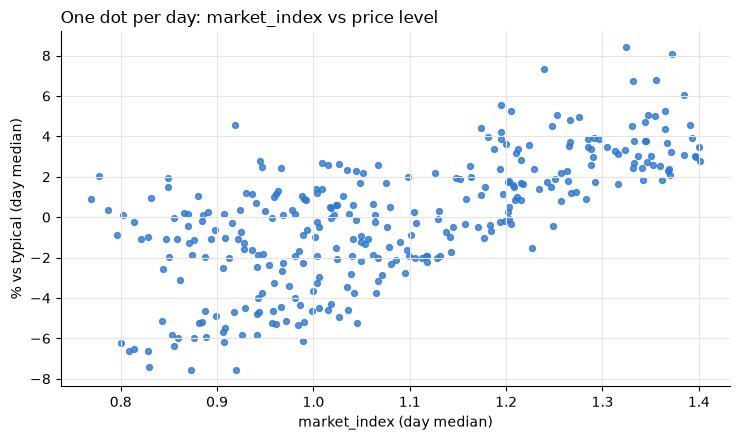

correlation between days:  0.68
correlation inside a day:  0.05


In [22]:
daily_level = clean.groupby("date").agg(
    price_level=("pct_vs_typical", "median"),
    market_index=("market_index", "median"),
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(daily_level["market_index"], daily_level["price_level"], s=18, color="#2a78d6", alpha=0.8)
ax.set_title("One dot per day: market_index vs price level", loc="left")
ax.set_xlabel("market_index (day median)")
ax.set_ylabel("% vs typical (day median)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e5e4e0", linewidth=0.8)
plt.tight_layout()
plt.show()

within = clean.dropna(subset=["market_index"]).copy()
within["mi_vs_day"] = within["market_index"] - within.groupby("date")["market_index"].transform("median")
within["price_vs_day"] = within["pct_vs_typical"] - within.groupby("date")["pct_vs_typical"].transform("median")

print("correlation between days:  %.2f" % daily_level["market_index"].corr(daily_level["price_level"]))
print("correlation inside a day:  %.2f" % within["mi_vs_day"].corr(within["price_vs_day"]))

### 6.2 Cities and lanes the model has never seen

In [23]:
train_cities = set(train["pickup"]) | set(train["delivery"])
val_cities = set(val["pickup"]) | set(val["delivery"])
unseen = sorted(val_cities - train_cities)

touches_unseen = val["pickup"].isin(unseen) | val["delivery"].isin(unseen)
train_lanes = set(train["pickup"] + " > " + train["delivery"])
unseen_lane = ~(val["pickup"] + " > " + val["delivery"]).isin(train_lanes)
coord_cols = ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]

print("cities in validation but never in train:", unseen)
print(f"validation rows touching an unseen city:   {touches_unseen.mean() * 100:.1f}%")
print(f"validation rows on a lane never seen:      {unseen_lane.mean() * 100:.1f}%")
print("missing coordinates in validation:        ", int(val[coord_cols].isna().sum().sum()))

cities in validation but never in train: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
validation rows touching an unseen city:   12.1%
validation rows on a lane never seen:      12.2%
missing coordinates in validation:         0


**Findings:**
- **Equipment:** Reefer about +8.5% and Flatbed about +4% vs typical, Dry Van about -4%. A clear, useful feature.
- **Weight:** heavier loads cost more, from about -5% (<10k lb) to about +3% (40-50k lb).
- **Month:** prices rise from about -5.5% in January to about +4.4% in June, then fall back. There is seasonality, but the model has never seen November or December, so "month" alone cannot tell it what Nov-Dec look like.
- **Day of week:** small effect (about -1% to +1%).
- **market_index:** it tracks the price level of the **day** (correlation about 0.68 between days) but says nothing inside a day (about 0.05). So it is a daily market signal, which is exactly what the model needs to place unseen Nov-Dec days.
- **Unseen cities:** 8 validation cities never appear in train (12% of validation rows). City names cannot help on those rows; coordinates can, and validation has no missing coordinates.

## Decisions log

| # | Decision | Reason |
|---|---|---|
| 1 | Treat missing `weight` and `market_index` as random (MCAR), no missing flag | Missing rows match the rest on rate per mile, distance, equipment and month (2.1, 2.2) |
| 2 | Fill missing `weight` with the global median, computed on train only | Missingness is random; the median is robust to outliers; equipment medians are almost equal (2.3) |
| 3 | Fill missing `market_index` with the median of the same day | `market_index` moves between days, not within a day; MAE 0.020 vs 0.143 for a global median (2.4) |
| 4 | Apply `abs()` to `weight` (train and validation) | Negative weights have the same magnitude distribution, price and spread as positive ones: only the sign is corrupted (2.6) |
| 5 | Fill missing `market_index` with the median of the same day; for validation days use the validation rows of that day (features only, no prices) | Train has no Nov-Dec days; same-day median error 0.020 vs 0.068-0.129 for train-based options (2.5) |
| 6 | Learn every statistic (weight median, thresholds, etc.) on the training part only, after the split, then apply it to the validation part | Avoids leakage from validation into training |
| 7 | Drop price outliers (`rpm_ratio` < 0.6 or > 1.6) from the training part only; keep them in our validation part and report error on all rows and on normal rows | They are 1.41% of rows, look like price errors (clean gap from the normal range), cannot be predicted from any feature, and double the spread of rate per mile (4) |
| 8 | Drop `quote_signal` from the model | In most of train it is the answer itself (= rate per mile, or its mirror 4.15 - rate per mile); in Nov-Dec it shows no link to price, like August; the December chart file does not have it (5) |
| 9 | December chart file: fill coordinates by city lookup from train; fill `market_index` with the same-day median of validation rows (December days have 191-227 rows each). Use `market_index` in the model only if it improves validation error | Each city has exactly one coordinate pair; `market_index` is a daily value, same logic as #5 |
| 10 | Validate with 3 expanding-window time folds: train Jan-Apr / validate May-Jun, train Jan-Jun / validate Jul-Aug, train Jan-Aug / validate Sep-Oct. Report the mean and spread of the error. Final model retrained on all Jan-Oct | The real task predicts the 2 months after the data ends, so each fold validates on the 2 months after its training data (no future leakage). Three periods give a more reliable number than one and show whether the model is stable across the year |
| 11 | Features: distance, weight, equipment, the 4 coordinates, `market_index`, month. Not used: `quote_signal`, city names, day of week. Target: log(rate per mile), price = rate per mile x distance | Compared in `src/experiments.py` over the 3 folds (MAE on normal rows): no time info $80.5, + market_index $72.6, + market_index + month $63.9 (folds 63/69/60), + linear trend $64.3 (folds 42/105/46, unstable trend estimate), + day of week made it worse. For Nov-Dec the model carries the latest level it learned (October) and `market_index` adjusts it day by day |
| 12 | Model: scikit-learn HistGradientBoostingRegressor (600 iterations, learning rate 0.05) on log(rate per mile), compared with a simple baseline (median rate per mile per distance band and equipment) | Same 3 folds, MAE on normal rows (`src/experiments.py`): decision tree $80, random forest $65, linear regression $64 (unstable, 53/83/55), LightGBM $64, XGBoost $64, HistGradientBoosting $62 (63/62/60, most stable), and no extra library. Final: $61.7 +-1.4 (2.6%) vs baseline $106.6 +-33.5 (4.7%) |
| 13 | Hyperparameters: learning_rate 0.03, max_leaf_nodes 15, min_samples_leaf 50, l2_regularization 1.0, early stopping (up to 1000 trees) | Grid search over 81 settings on the same 3 folds (`src/tune.py`). MAE on normal rows $61.67 -> $60.54; equal or better on every fold (63.0/61.8/60.1 -> 62.8/58.7/60.1). All 81 settings fall between $60.5 and $64.0, so the model is not sensitive to settings; the top settings consistently favour more regularization (larger leaves, L2 penalty). Selected on the same folds, so the tuned score is slightly optimistic |


## Open questions

None. EDA complete; next step is the modeling pipeline in `src/`.